# Layer 3: Movement Segmentation

Splits the master pose sequence into 19 Chon-Ji movement boundaries
using velocity-valley detection and (optionally) keypose matching.

**Input**: `sample_videos/chon_ji_master_poses.json`  
**Also reads**: `master_data/chon_ji/keyposes.json` (empty until marked by instructor)  
**Output**: boundary table + segment-length histogram

In [1]:
import sys, pathlib, warnings
project_root = pathlib.Path().resolve().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print(f"project_root: {project_root}")

project_root: E:\Projects\Saas\Taekwon


In [2]:
from itf_analysis.segmentation.segmentor import (
    load_poses_from_json,
    compute_velocity_signal,
    smooth_velocity,
    normalize_velocity,
    compute_expected_frames,
    segment_video,
    VELOCITY_JOINTS,
)
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

POSES_PATH    = str(project_root / "itf_analysis" / "sample_videos" / "chon_ji_master_poses.json")
KEYPOSES_PATH = str(project_root / "itf_analysis" / "master_data" / "chon_ji" / "keyposes.json")
NUM_MOVEMENTS = 19

In [3]:
frames = load_poses_from_json(POSES_PATH)
print(f"Frames loaded: {len(frames)}")

Frames loaded: 1153


## Velocity signal

Raw vs. smoothed velocity. Check that the smoothed curve shows
clear valleys — ideally ≥ 19 are visible before running segmentation.

Global valley count: 29  (need ≥ 19)


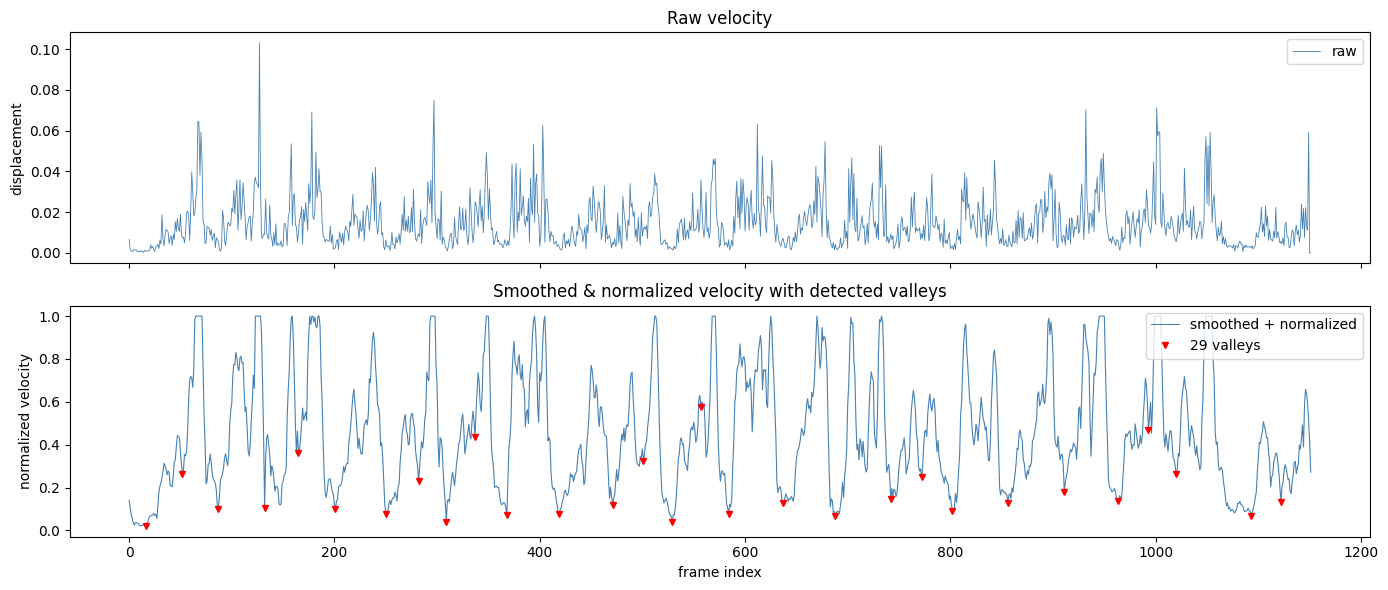

In [4]:
raw_v    = compute_velocity_signal(frames)
smooth_v = smooth_velocity(raw_v)
norm_v   = normalize_velocity(smooth_v)

# Global diagnostic: how many valleys does find_peaks detect?
N = len(frames)
half_w = max(1, int(N / NUM_MOVEMENTS * 0.45))
valleys, _ = find_peaks(-norm_v, prominence=0.02, distance=half_w)
print(f"Global valley count: {len(valleys)}  (need ≥ {NUM_MOVEMENTS})")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(raw_v, linewidth=0.6, color='steelblue', label='raw')
axes[0].set_ylabel('displacement')
axes[0].set_title('Raw velocity')
axes[0].legend()

axes[1].plot(norm_v, linewidth=0.8, color='steelblue', label='smoothed + normalized')
axes[1].plot(valleys, norm_v[valleys], 'rv', markersize=5, label=f'{len(valleys)} valleys')
axes[1].set_ylabel('normalized velocity')
axes[1].set_xlabel('frame index')
axes[1].set_title('Smoothed & normalized velocity with detected valleys')
axes[1].legend()

plt.tight_layout()
plt.show()

## Run segmentation (master-on-master)

In [5]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always')
    boundaries = segment_video(
        student_frames=frames,
        keyposes_path=KEYPOSES_PATH,
        master_total_frames=len(frames),
    )

if caught:
    print(f"{len(caught)} warning(s):")
    for w in caught:
        print(f"  {w.message}")
else:
    print("No warnings.")

No warnings.


## Boundary table

In [7]:
print(f"{'Mov':>4} {'start':>6} {'end':>6} {'length':>7} {'expected':>9} {'conf':>8}  {'v_frame':>8} {'v_prom':>7}")
print("-" * 70)
for b in boundaries:
    length = b.end_frame - b.start_frame + 1
    vp = f"{b.velocity_prominence:.3f}" if b.velocity_prominence is not None else "  —"
    print(f"{b.movement_index:>4} {b.start_frame:>6} {b.end_frame:>6} "
          f"{length:>7} {b.expected_frame:>9} {b.confidence:>8}  "
          f"{str(b.velocity_frame):>8} {vp:>7}")

from collections import Counter
conf_dist = Counter(b.confidence for b in boundaries)
print(f"\nConfidence: high={conf_dist['high']}  medium={conf_dist['medium']}  low={conf_dist['low']}")

 Mov  start    end  length  expected     conf   v_frame  v_prom
----------------------------------------------------------------------
   1      0     87      88        61   medium        87   0.900
   2     88    132      45       121   medium       132   0.893
   3    133    201      69       182   medium       201   0.902
   4    202    250      49       243   medium       250   0.917
   5    251    309      59       303   medium       309   0.960
   6    310    368      59       364   medium       368   0.926
   7    369    419      51       425   medium       419   0.925
   8    420    471      52       485   medium       471   0.883
   9    472    529      58       546   medium       529   0.960
  10    530    584      55       607   medium       584   0.925
  11    585    688     104       668   medium       688   0.932
  12    689    742      54       728   medium       742   0.854
  13    743    802      60       789   medium       802   0.906
  14    803    856      54       

## Boundary visualization on velocity curve

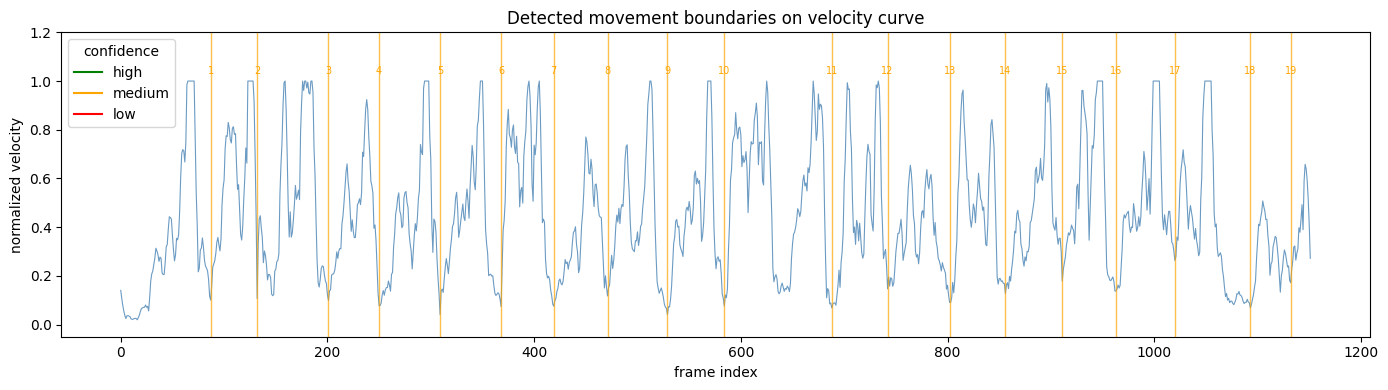

In [8]:
colour_map = {'high': 'green', 'medium': 'orange', 'low': 'red'}

plt.figure(figsize=(14, 4))
plt.plot(norm_v, linewidth=0.8, color='steelblue', alpha=0.8)

for b in boundaries:
    colour = colour_map[b.confidence]
    plt.axvline(b.boundary_frame, color=colour, linewidth=1.0, alpha=0.7)
    plt.text(b.boundary_frame, 1.02, str(b.movement_index),
             ha='center', va='bottom', fontsize=7, color=colour)

from matplotlib.lines import Line2D
legend_handles = [Line2D([0], [0], color=c, label=l)
                  for l, c in colour_map.items()]
plt.legend(handles=legend_handles, title='confidence')
plt.xlabel('frame index')
plt.ylabel('normalized velocity')
plt.title('Detected movement boundaries on velocity curve')
plt.ylim(-0.05, 1.2)
plt.tight_layout()
plt.show()

## Segment length distribution

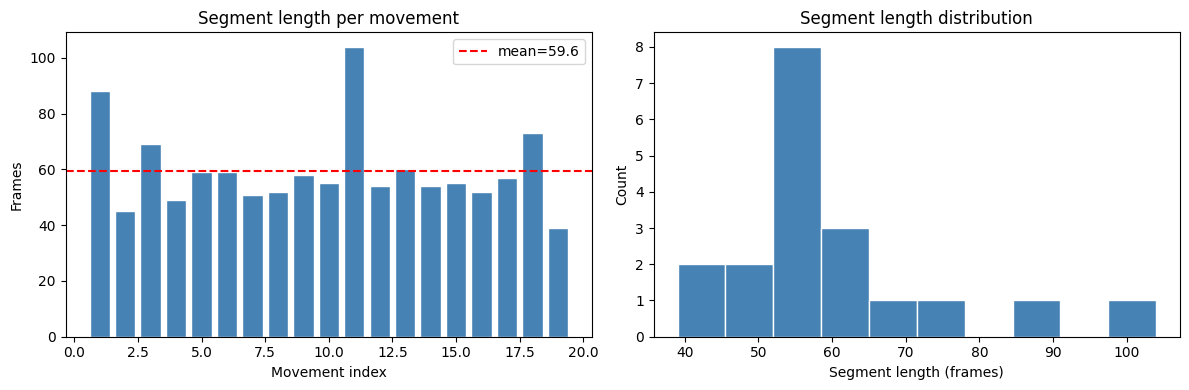

Min: 39  Max: 104  Mean: 59.6  Std: 14.7


In [9]:
lengths = [b.end_frame - b.start_frame + 1 for b in boundaries]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 20), lengths, color='steelblue', edgecolor='white')
axes[0].axhline(np.mean(lengths), color='red', linestyle='--', label=f'mean={np.mean(lengths):.1f}')
axes[0].set_xlabel('Movement index')
axes[0].set_ylabel('Frames')
axes[0].set_title('Segment length per movement')
axes[0].legend()

axes[1].hist(lengths, bins=10, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Segment length (frames)')
axes[1].set_ylabel('Count')
axes[1].set_title('Segment length distribution')

plt.tight_layout()
plt.show()

print(f"Min: {min(lengths)}  Max: {max(lengths)}  Mean: {np.mean(lengths):.1f}  Std: {np.std(lengths):.1f}")

## Validation Checklist

- [ ] Global valley count ≥ 19 before segmentation
- [ ] All 19 boundaries detected (no crash)
- [ ] boundary_frames strictly monotonically increasing
- [ ] Segment lengths roughly uniform (no extreme outliers)
- [ ] Low-confidence boundaries < 3  
- [ ] After marking keyposes.json: re-run and confirm high-confidence count ≥ 15

**Self-match gate**: running master video through its own keyposes must yield
all 19 movements as "high" confidence before testing student videos.